In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  




In [ ]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.functions import Functions
from region import Region
fns = Functions()

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import seaborn as sns
from cartopy.feature import LAND
from scipy.stats import pearsonr


In [4]:
elevation_ = GEBCO(coarsen_factor=4).ds.elevation

In [5]:
sla_ = SLA(deg=0.25).da
winds_ = xr.open_dataset('../data/ef25db236e60a21a34ee2e0b4631d366.nc').sortby('latitude').rename({'valid_time':'time'})
sam = xr.open_dataarray('sam.nc').sel(time=slice(sla_.time[0],winds_.time[-1]))
sice_ = xr.open_dataset('../data/NSIDC/sice_processed.nc').__xarray_dataarray_variable__
sip_ = xr.open_dataarray('sip.nc')



In [6]:
gyre_index = xr.open_dataarray('gyre_index.nc')

In [7]:
extent_ac = [138,152,-68,-63]
extent_ea = [60,160,-70,-60]
extent_sip= [140,146,-67,-66.5]

elevation_ea = elevation_.sel(latitude = slice(extent_ea[2], extent_ea[3]), longitude = slice(extent_ea[0],extent_ea[1]))
elevation_ac = elevation_.sel(latitude = slice(extent_ac[2], extent_ac[3]), longitude = slice(extent_ac[0],extent_ac[1]))

In [8]:
sip_.load()

<xarray.DataArray (time: 174, index: 7443)> Size: 10MB
array([[0.      , 0.      , 0.      , ..., 0.66075 , 0.706299, 0.622608],
       [0.      , 0.      , 0.      , ..., 0.301758, 0.601084, 0.798559],
       [0.      , 0.      , 0.      , ..., 0.432193, 0.550932, 0.427434],
       ...,
       [0.      , 0.      , 0.      , ..., 0.779148, 0.704398, 0.774911],
       [0.      , 0.      , 0.      , ..., 0.177497, 0.262051, 0.233732],
       [0.      , 0.      , 0.      , ..., 0.296595, 0.299498, 0.323815]],
      shape=(174, 7443))
Coordinates:
  * time       (time) datetime64[ns] 1kB 2002-07-01 2002-08-01 ... 2024-10-01
    month      (time) int64 1kB 7 8 9 10 3 4 5 6 7 8 9 ... 9 10 3 4 5 6 7 8 9 10
  * index      (index) int64 60kB 0 1 2 3 4 5 ... 7437 7438 7439 7440 7441 7442
    lat        (index) float64 60kB -69.98 -69.97 -69.93 ... -65.01 -65.02
    lon        (index) float64 60kB 138.0 138.2 138.1 ... 149.7 149.6 149.9
    latitude   (index) float64 60kB -69.98 -69.97 -69.93 ... -65.01 -65.02
    longitude  (index) float64 60kB 138.0 138.2 138.1 ... 149.7 149.6 149.9
    elevation  (index) float64 60kB nan -290.2 -464.2 ... nan -3.251e+03

In [9]:
sip = sip_.where((sip_.lon > extent_ac[0]) & (sip_.lon < extent_ac[1]) &  (sip_.lat > extent_ac[2]) & (sip_.lat < extent_ac[3]))

In [10]:
region_ac = Region('AC',extent_ac,elevation=elevation_ac)
region_ac_shelf = Region('ACS',extent_ac,elevation=elevation_ac,min_elevation=-1000)
region_ea = Region('EA',extent_ea)

extent_gyre = [145,149,-66.5,-65.5]
region_gyre = Region('Gyre',extent=extent_gyre)

region_sip = Region('SIP',extent_sip)

winds_ea = region_ea.crop_da(winds_)

sla = region_ac.crop_da(sla_)
sla_shelf = region_ac_shelf.crop_da(sla_)
sla_gyre = region_gyre.crop_da(sla_)
winds = region_ac.crop_da(winds_)
sice = region_ac.crop_da(sice_)
sic_sip = region_sip.crop_da(sice_)
sip_shelf = sip.where(sip.elevation > -1000,drop=True)


# filter dodgy sla signal
lonboo = sla.longitude < 147
latboo = sla.latitude > -66.6
sla = sla.where(lonboo | latboo,drop=True)

In [11]:
u,v = fns.get_geostrophic_currents(sla)
geos = xr.Dataset({'u10':u,'v10':v})

In [12]:
sa_sla = fns.seasonal_anomaly(sla.interpolate_na(dim='time'))
sa_geos = fns.seasonal_anomaly(geos.interpolate_na(dim='time'))
sa_winds = fns.seasonal_anomaly(winds.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
sa_sic = fns.seasonal_anomaly(sice.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
sa_sics = fns.seasonal_anomaly(sic_sip.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))

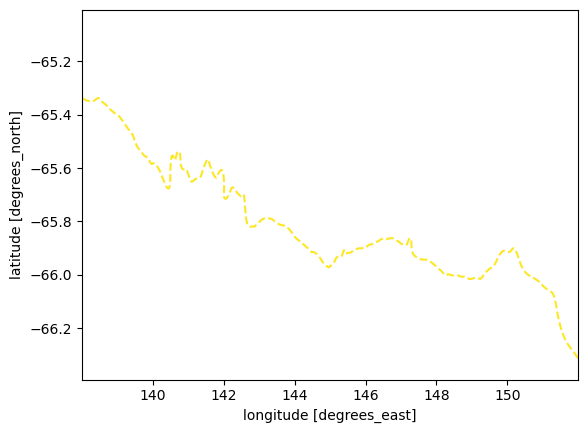

In [13]:
cc=elevation_ac.sel(latitude=slice(-66.4,-65)).plot.contour(levels=[-1000])

In [14]:
lats = xr.DataArray(cc.allsegs[0][0].T[1],coords={'longitude':cc.allsegs[0][0].T[0]})
asclats = lats.sortby('longitude').interp(longitude=geos.longitude,kwargs={'fill_value':'extrapolate'})

In [15]:
# isolate asc on slope = -1000
geos['asc_latitude'] = xr.DataArray(asclats,coords={'longitude':geos.longitude})
geos['asc'] = geos.u10.sel(latitude=geos.asc_latitude,method='nearest')

In [16]:
R = 6371000
lat_radians = np.deg2rad(geos.asc_latitude)

dx = R * np.cos(lat_radians[:-1]) * np.deg2rad(np.diff(geos.longitude))
dy = R * np.deg2rad(np.diff(geos.asc_latitude))

delta = np.stack([dx,dy],axis=1)
t_hat = delta / np.linalg.norm(delta, axis=1)[:, None]

In [17]:
# Interpolate u and v onto path points for all times
u_path = geos.u10.interp(latitude=geos.asc_latitude, longitude=geos.longitude)
v_path = geos.v10.interp(latitude=geos.asc_latitude, longitude=geos.longitude)
# We project using the unit vector of each segment; use the starting point of each segment
u_seg = u_path[:, :-1]  # drop last point (segments)
v_seg = v_path[:-1, :]

In [18]:
dathatx = xr.DataArray(t_hat[:,0],coords={'longitude':u_seg.longitude})
dathaty = xr.DataArray(t_hat[:,1],coords={'longitude':u_seg.longitude})
v_along = u_seg * dathatx + v_seg * dathaty # shape: (time, segments)

In [19]:
# strength of easterlies and westerlies
def windstrength(data,minlat,maxlat):
    westerly_range = data.sel(latitude=slice(minlat,maxlat))
    weights = np.cos(np.deg2rad(westerly_range.latitude))
    return westerly_range.weighted(weights).mean(dim=["latitude", "longitude"])

eastl = -windstrength(winds.u10,-68,-64)#-winds.u10.sel(latitude=slice(-68,-65)).mean(['latitude','longitude'])
westl = windstrength(winds.u10,-65,-55)#winds.u10.sel(latitude=slice(-64,-55)).mean(['latitude','longitude'])
# strength of ASC/ACC
#asc = geos.u10.sel(latitude=slice(-66.25,-65.5)).mean(['latitude','longitude'])
acc = windstrength(geos.u10,-65,-63)#geos.u10.sel(latitude=slice(-65,-63)).mean(['latitude','longitude'])
# coastal ssh
cssh = sla_shelf.mean(['latitude','longitude'])
csic = sic_sip.mean(['latitude','longitude'])
gssh = sla_gyre.mean(['latitude','longitude'])
# sha & grace
csip = sip_shelf.mean('index').broadcast_like(cssh.time)

In [20]:
# new asc
asc = -v_along.mean('longitude')

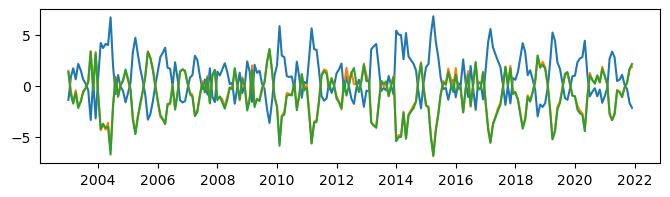

In [21]:
fig,ax = plt.subplots(figsize=(8,2))
ax.plot(geos.time,asc)
ax.plot(geos.time,geos.asc.mean('longitude'))
ax.plot(geos.time,v_along.mean('longitude'))

In [22]:
colors = plt.cm.tab20b(np.linspace(0, 0.75, 4))


Rendering..


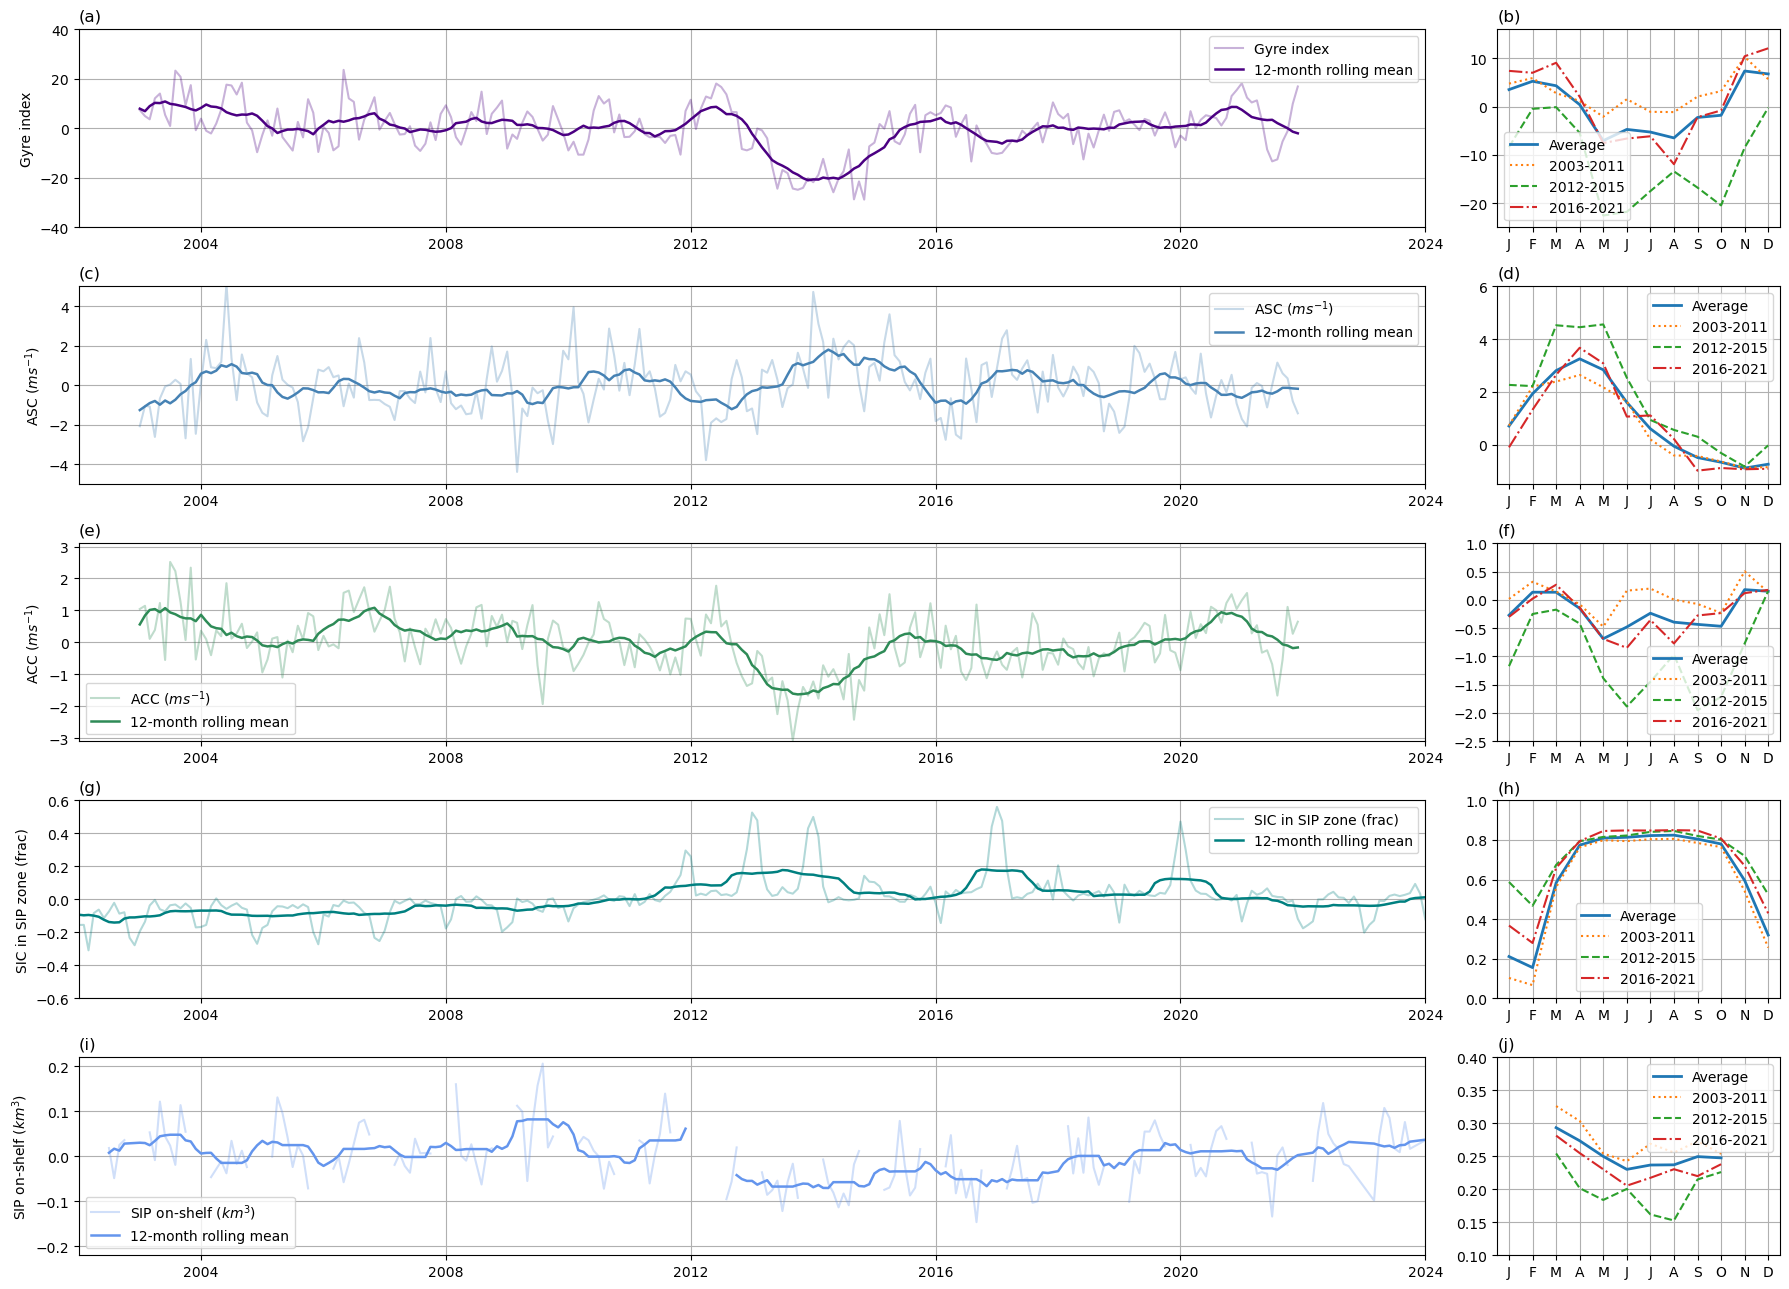

In [40]:
t0 = acc.time[0]
t1 = pd.Timestamp(2012,12,31)
t2 = pd.Timestamp(2015,12,31)
t3 = acc.time[-1]


fig = plt.figure(figsize=(18,13))
axs=[]

gs = fig.add_gridspec(5,5)

def add_row(n,var,varname,ylim=[-16,16],ylim_cmt=[-7,7],anom=False,titles=[None,None],color='grey'):

    axs.append(fig.add_subplot(gs[n,0:4]))
    axs.append(fig.add_subplot(gs[n,4:6]))

    if 'latitude' in var.dims:
        da = var.mean(['latitude','longitude'])
    else:
        da = var
        
    cmt = da.groupby('time.month').mean()

    cmt1 = da.sel(time=slice(t0,t1)).groupby('time.month').mean()
    cmt2 = da.sel(time=slice(t1,t2)).groupby('time.month').mean()
    cmt3 = da.sel(time=slice(t2,t3)).groupby('time.month').mean()

    ax = axs[(n*2)]

    if anom:
        da = da.groupby('time.month') - cmt
        #varname = varname + ' (seasonal anomaly)'

    ax.plot(da.time,da,label=varname,c=color,alpha=0.3)
    ax.plot(da.time,da.rolling(time=12,center=True,min_periods=4).mean(),label='12-month rolling mean',c=color,linewidth=1.8)

    ax.set_ylabel(varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2002,1,1),pd.Timestamp(2024,1,1)])
    ax.grid()
    ax.set_title(titles[0],loc='left')

    ax = axs[(n*2)+1]

    ax.plot(cmt.month,cmt,linewidth=2,label='Average')

    ax.plot(cmt.month,cmt1,linestyle=':',label='2003-2011')
    ax.plot(cmt.month,cmt2,linestyle='--',label='2012-2015')
    ax.plot(cmt.month,cmt3,linestyle='-.',label='2016-2021')
    ax.set_ylim(ylim_cmt)
    ax.grid()
    ax.set_xticks(cmt.month,labels=['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])
    ax.legend()
    ax.set_title(titles[1],loc='left')



add_row(0,gyre_index,'Gyre index',anom=True,ylim=[-40,40],ylim_cmt=[-25,16],titles=['(a)','(b)'],color='indigo')
add_row(1,asc,'ASC ($ms^{-1}$)',anom=True,ylim=[-5,5],ylim_cmt=[-1.5,6],titles=['(c)','(d)'],color='steelblue') # (geostrophic gradient on slope)
add_row(2,acc,'ACC ($ms^{-1}$)',anom=True,ylim=[-3.1,3.1],ylim_cmt=[-2.5,1],titles=['(e)','(f)'],color='seagreen') # (geostrophic gradient at 63-65S)
add_row(3,csic,'SIC in SIP zone (frac)',anom=True,ylim=[-0.6,0.6],ylim_cmt=[0,1],titles=['(g)','(h)'],color='teal')
add_row(4,csip,'SIP on-shelf ($km^3$)',anom=True,ylim=[-0.22,0.22],ylim_cmt=[0.1,0.4],titles=['(i)','(j)'],color='cornflowerblue')



plt.tight_layout()
print('Rendering..')


Rendering..


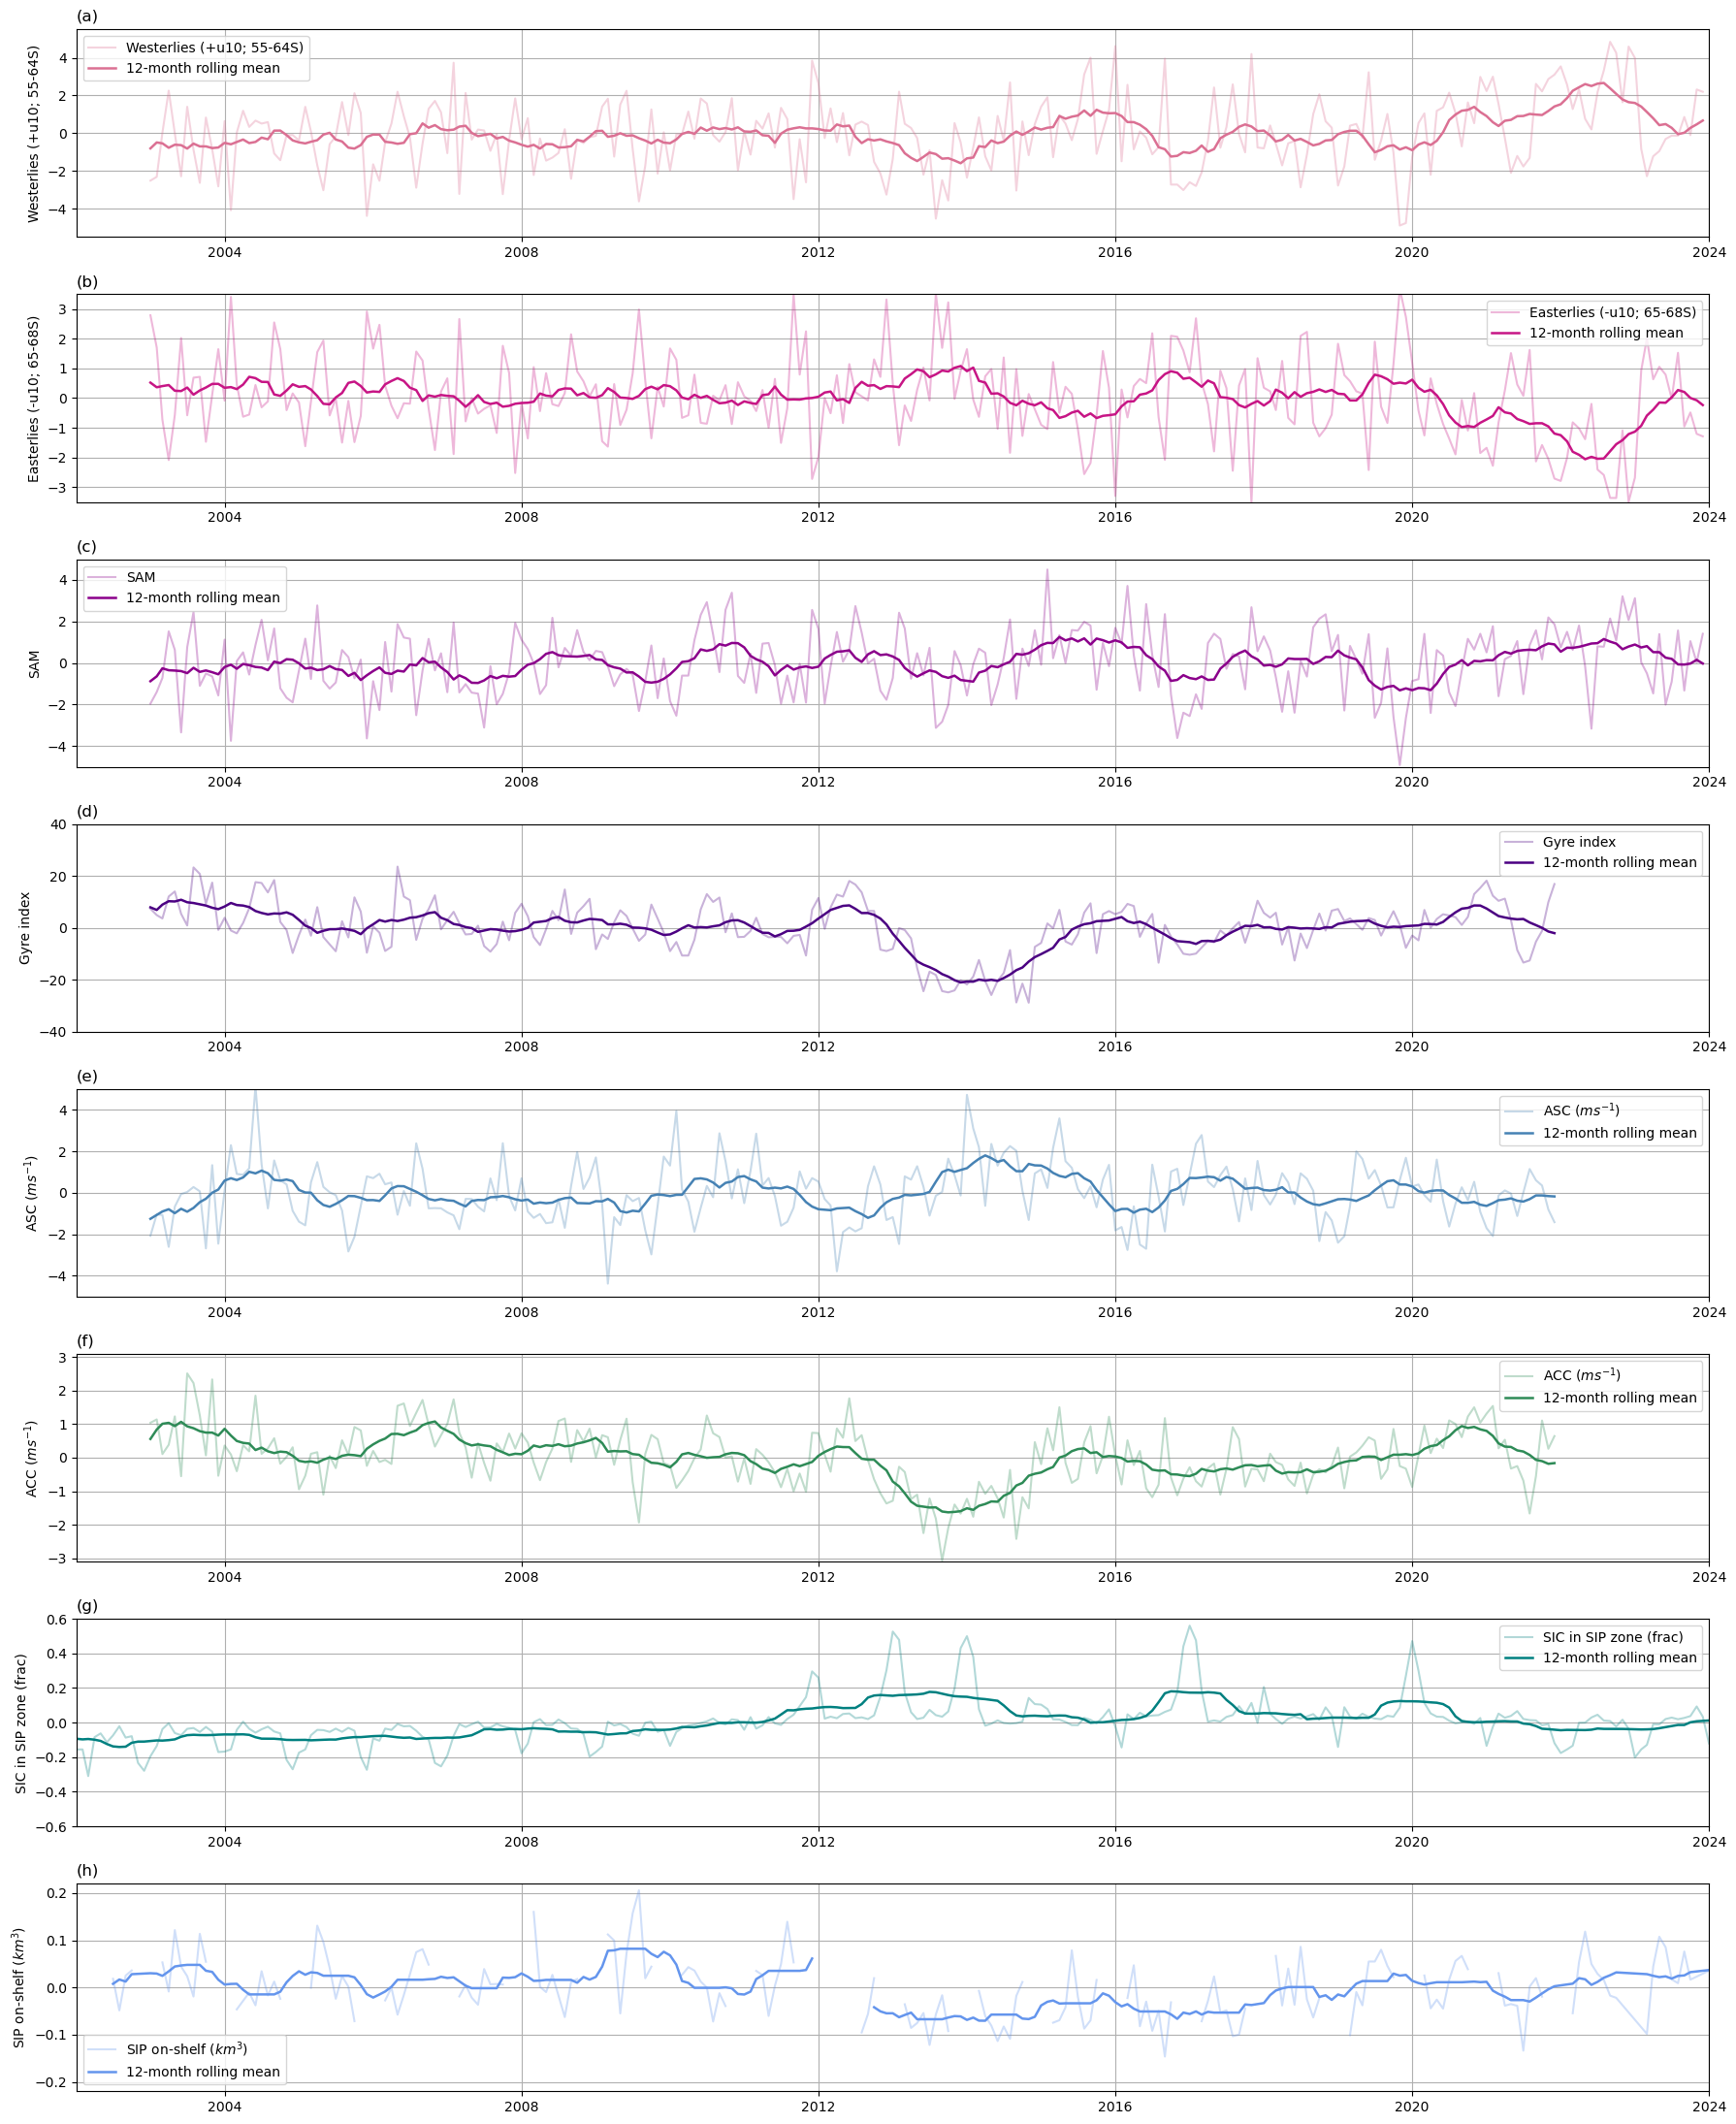

In [41]:



fig,axs = plt.subplots(8,1,figsize=(18,22))

def add_row(n,var,varname,ylim=[-16,16],anom=False,title=None,color='grey'):

    ax=axs[n]

    if 'latitude' in var.dims:
        da = var.mean(['latitude','longitude'])
    else:
        da = var
        

    if anom:
        cmt = da.groupby('time.month').mean()
        da = da.groupby('time.month') - cmt
        #varname = varname + ' (seasonal anomaly)'

    ax.plot(da.time,da,label=varname,c=color,alpha=0.3)
    ax.plot(da.time,da.rolling(time=12,center=True,min_periods=4).mean(),label='12-month rolling mean',c=color,linewidth=1.8)

    ax.set_ylabel(varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2002,1,1),pd.Timestamp(2024,1,1)])
    ax.grid()
    ax.set_title(title,loc='left')


add_row(0,westl,'Westerlies (+u10; 55-64S)',anom=True,ylim=[-5.5,5.5],title='(a)',color='palevioletred')
add_row(1,eastl,'Easterlies (-u10; 65-68S)',anom=True,ylim=[-3.5,3.5],title='(b)',color='mediumvioletred')
add_row(2,sam,'SAM',anom=True,ylim=[-5,5],title='(c)',color='darkmagenta')
add_row(3,gyre_index,'Gyre index',anom=True,ylim=[-40,40],title='(d)',color='indigo')
add_row(4,asc,'ASC ($ms^{-1}$)',anom=True,ylim=[-5,5],title='(e)',color='steelblue') # (geostrophic gradient on slope)
add_row(5,acc,'ACC ($ms^{-1}$)',anom=True,ylim=[-3.1,3.1],title='(f)',color='seagreen') # (geostrophic gradient at 63-65S)
add_row(6,csic,'SIC in SIP zone (frac)',anom=True,ylim=[-0.6,0.6],title='(g)',color='teal')
add_row(7,csip,'SIP on-shelf ($km^3$)',anom=True,ylim=[-0.22,0.22],title='(h)',color='cornflowerblue')



plt.tight_layout()
print('Rendering..')


In [ ]:
#repeat with extra plots
sose140 = xr.open_dataset('sose_shelf_140.nc')
sose145 = xr.open_dataset('sose_shelf_145.nc')

In [ ]:
sigdiff = xr.open_dataarray('sigdiff.nc')

In [ ]:
ssal = sose145.SALT.sel(Z=slice(0,-500)).mean(['Z','YC'])
sthe = sose145.THETA.sel(Z=slice(0,-500)).mean(['Z','YC'])

In [ ]:

var1 = fns.seasonal_anomaly(ssal)# sose145.SALT.integrate('Z').mean(['YC']
vars = [fns.seasonal_anomaly(var) for var in [cssh,westl,eastl,asc,sam,acc,csic]]


lags = np.arange(-12,13,1)
cmat = np.empty((len(vars),len(lags)))
pmat = np.empty((len(vars),len(lags)))


ts = cssh.time[0]

for i,v in enumerate(vars):
    for j,w in enumerate(lags):
        var1_shifted = var1.assign_coords(
            time=pd.to_datetime(var1.time.values) + pd.DateOffset(months=w)
        )
        vw, wv = xr.align(v,var1_shifted)#.shift({'time':w}))
        cmat[i][j] = xr.corr(vw,wv).item()
        pmat[i][j] = pearsonr(vw, wv)[1]

In [30]:
matt = pd.DataFrame(cmat.T,columns=['SLA','W-LIES','E-LIES','ASC','SAM','ACC','SIC'],index=[str(n) for n in lags])

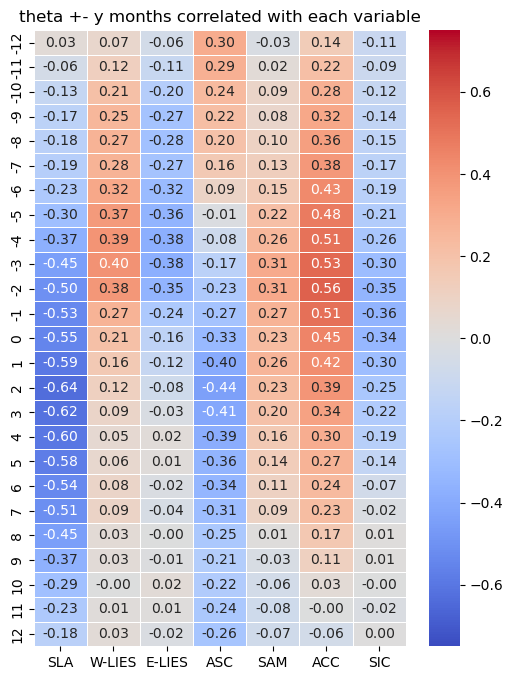

In [31]:
plt.figure(figsize=(6,8))
sns.heatmap(matt, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-0.75,vmax=0.75)
plt.title("theta +- y months correlated with each variable")
plt.show()

In [32]:
def mshift(da,m):
    return da.assign_coords(
            time=pd.to_datetime(da.time.values) + pd.DateOffset(months=m)
        )

def laglbl(lag):
    if lag >-1:
      txt = f'+{lag:.0f} mo.'
    else:
      txt = f'{lag:.0f} mo.'
    return txt

In [33]:
vars = [fns.seasonal_anomaly(var) for var in [westl,eastl,gyre_index,asc,acc,csic,csip,sthe,ssal]]#,sigdiff]]
lags = np.arange(-6,7,1)

cmat = np.empty((len(vars),len(vars)))
lmat = np.empty((len(vars),len(vars)))


ts = cssh.time[0]

for i,var1 in enumerate(vars):
    cmatl = np.empty((len(lags)))

    for j,v in enumerate(vars):
        for k,w in enumerate(lags):
            vw, wv = xr.align(v,mshift(var1,w))#var1.shift({'time':w}))
            cmatl[k] = xr.corr(vw,wv).item()
        abs_cmatl = np.abs(cmatl)
        cmat[i][j] = cmatl[max(range(len(abs_cmatl)), key=abs_cmatl.__getitem__)]
        lmat[i][j] = lags[max(range(len(abs_cmatl)), key=abs_cmatl.__getitem__)]

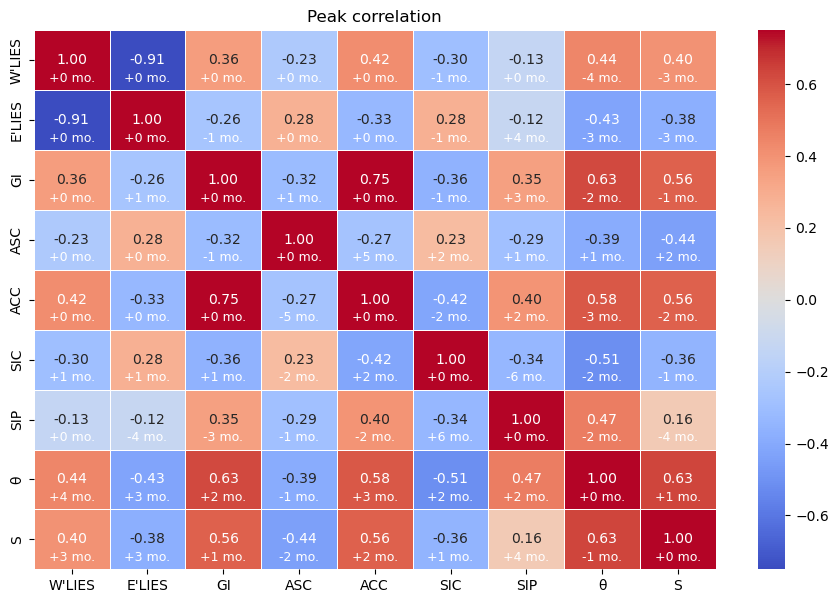

In [34]:
lbls = ["W'LIES","E'LIES",'GI','ASC','ACC','SIC','SIP','θ','S',]
matt = pd.DataFrame(cmat,columns=lbls,index=lbls)

fig,ax = plt.subplots(figsize=(11,7))
sns.heatmap(matt, ax=ax, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5,vmin=-0.75,vmax=0.75)
ax.set_title("Peak correlation")

#matl = pd.DataFrame(lmat,columns=lbls,index=lbls)
# plt.figure(figsize=(6,4))
# sns.heatmap(matt, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5,vmin=-12,vmax=23)
# plt.title("Correlation Heatmap")
# plt.show()

#ax=plt.gca()

for i in range (lmat.shape[0]):
  for j in range(lmat.shape[1]):
    lag = lmat[i,j]
    if lag >-1:
      txt = f'+{lag:.0f} mo.'
    else:
      txt = f'{lag:.0f} mo.'
    ax.text(i + 0.5, j + 0.8, txt,
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=9,
            color='w')

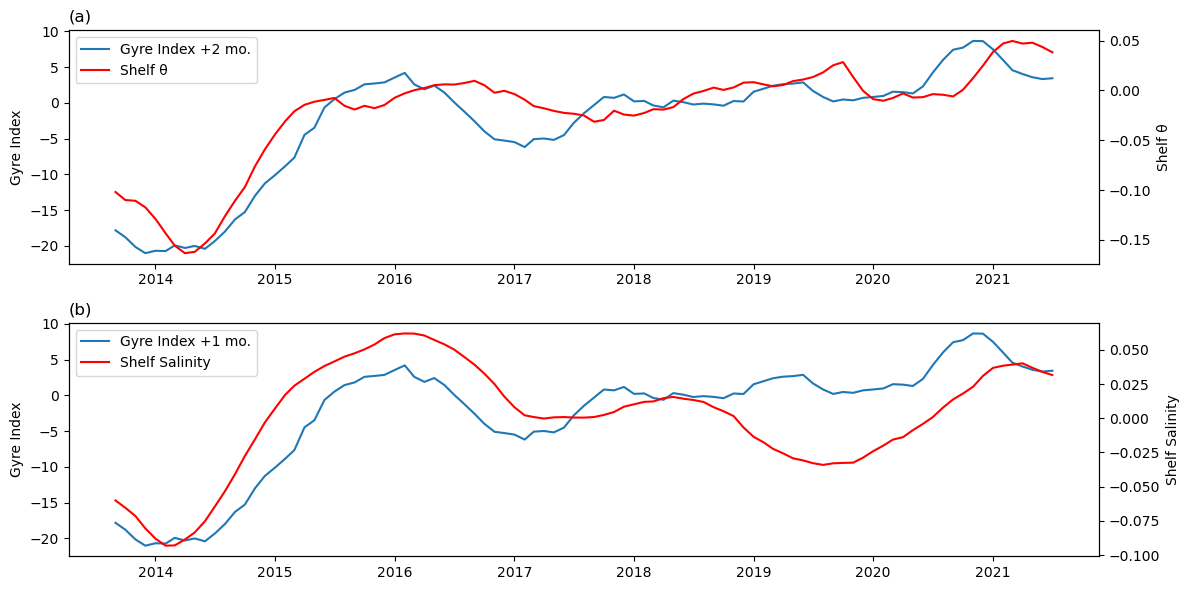

In [41]:
a = fns.seasonal_anomaly(gyre_index)
alabel='Gyre Index'
b = fns.seasonal_anomaly(sthe)
blabel='Shelf θ'
lag=2

fig, axs = plt.subplots(2,1,figsize=(12,6))
ax = axs[0]

a,b = xr.align(a,mshift(b,lag))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
ax.set_ylabel('Gyre Index')
ax2=ax.twinx()
l2=ax2.plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel + ' ' + laglbl(lag),blabel])
ax2.set_ylabel(blabel)
ax.set_title('(a)',loc='left')

ax=axs[1]
b = fns.seasonal_anomaly(ssal)
blabel='Shelf Salinity'
lag=1

a,b = xr.align(a,mshift(b,lag))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
ax.set_ylabel('Gyre Index')
ax2=ax.twinx()
l2=ax2.plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel + ' ' + laglbl(lag),blabel])
ax2.set_ylabel(blabel)
ax.set_title('(b)',loc='left')



plt.tight_layout()

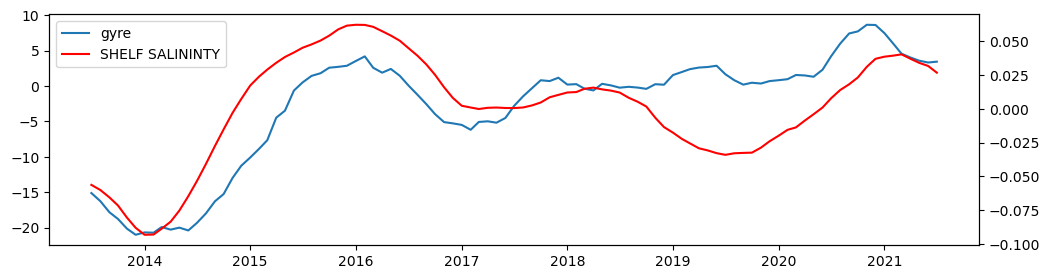

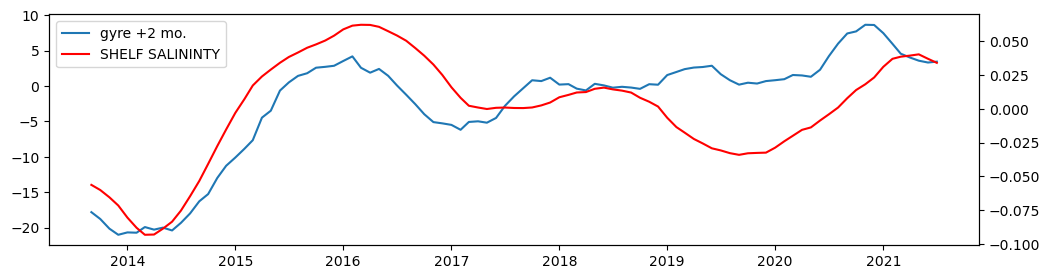

In [50]:
a = fns.seasonal_anomaly(gyre_index)
alabel='gyre'
b = fns.seasonal_anomaly(ssal)
blabel='SHELF SALININTY'
lag=2

a,b = xr.align(a,b)
fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

a,b = xr.align(a,mshift(b,lag))
fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel + ' ' + laglbl(lag),blabel])


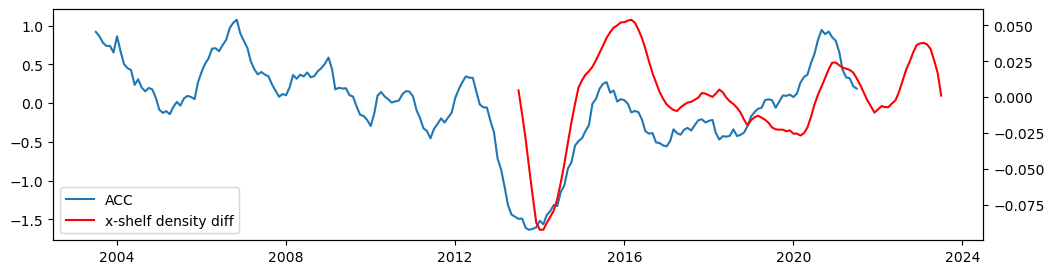

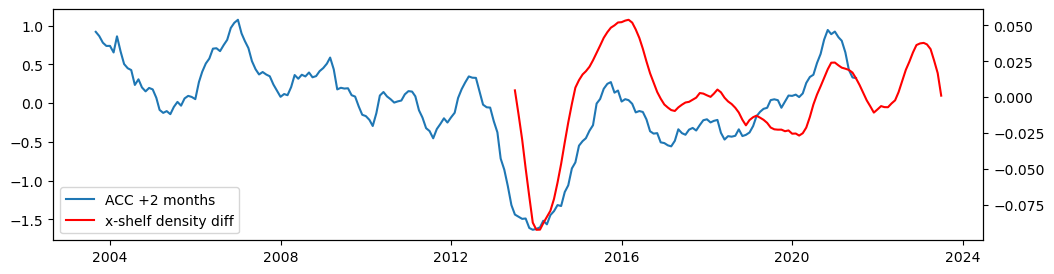

In [46]:
a = fns.seasonal_anomaly(acc)
alabel='ACC'
b = fns.seasonal_anomaly(sigdiff)
blabel='x-shelf density diff'

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.shift({'time':2}).rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel+ ' +2 months',blabel])

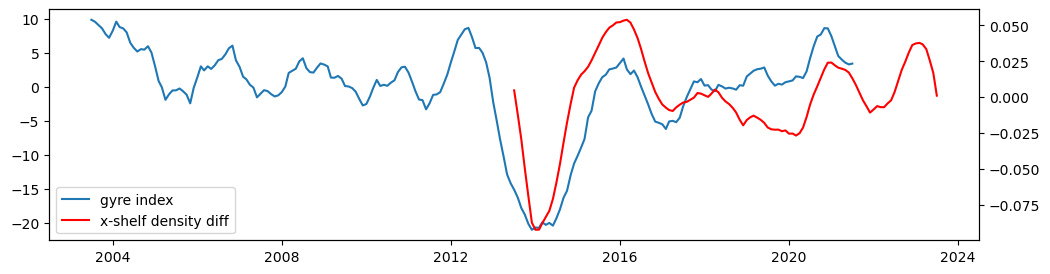

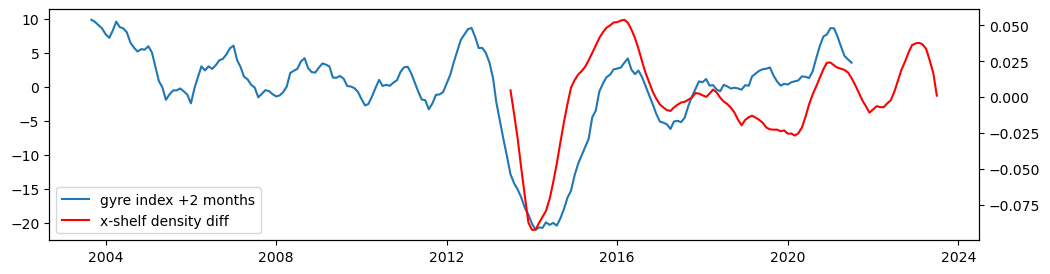

In [47]:
a = fns.seasonal_anomaly(gyre_index)
alabel='gyre index'
b = fns.seasonal_anomaly(sigdiff)
blabel='x-shelf density diff'

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.shift({'time':2}).rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel+ ' +2 months',blabel])

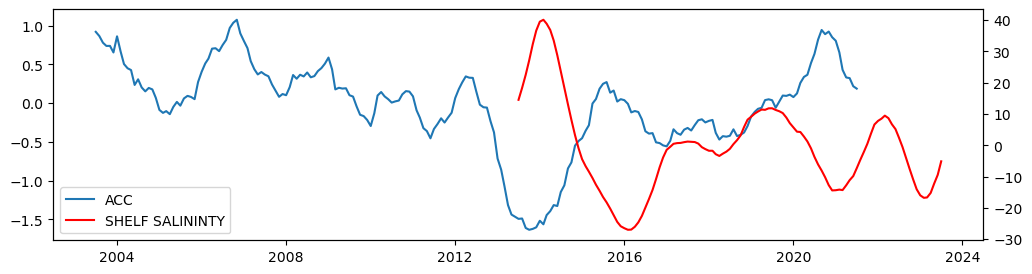

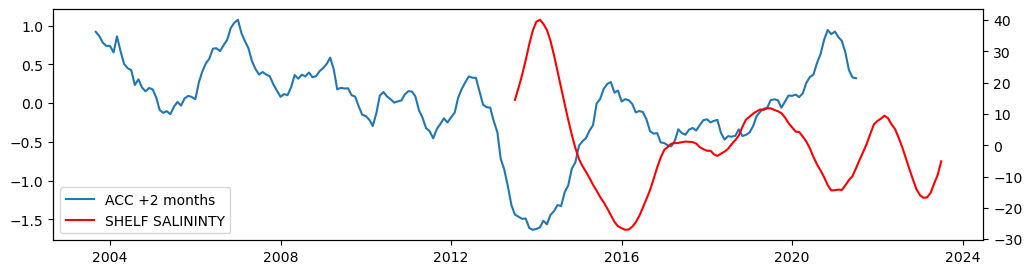

In [48]:
a = fns.seasonal_anomaly(acc)
alabel='ACC'
b = fns.seasonal_anomaly(sose145.SALT.integrate('Z').mean(['YC']))
blabel='SHELF SALININTY'

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.shift({'time':2}).rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel+ ' +2 months',blabel])

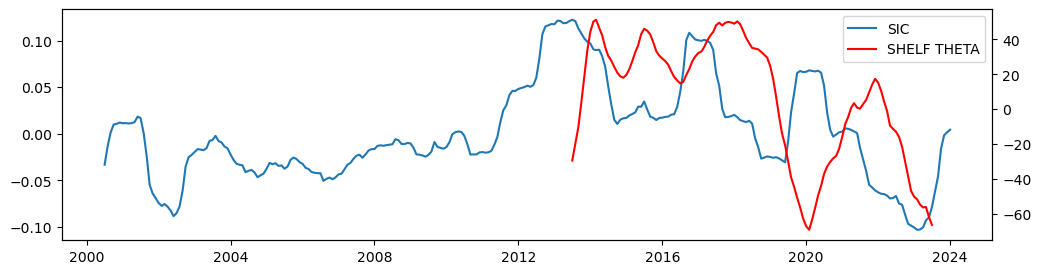

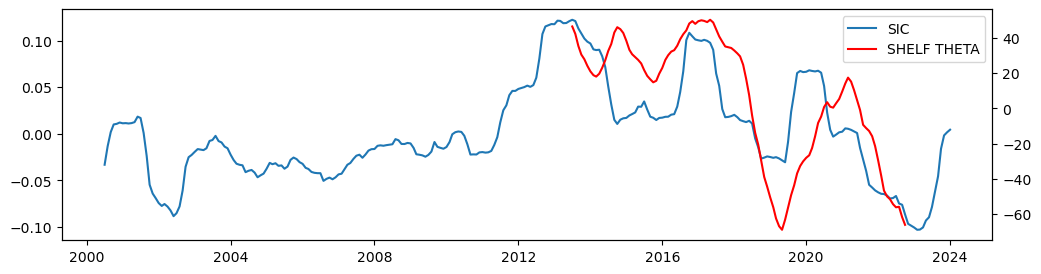

In [49]:
a = fns.seasonal_anomaly(csic)
alabel='SIC'
b = fns.seasonal_anomaly(sose145.THETA.integrate('Z').mean(['YC']))
blabel='SHELF THETA'

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.shift({'time':-9}).rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])


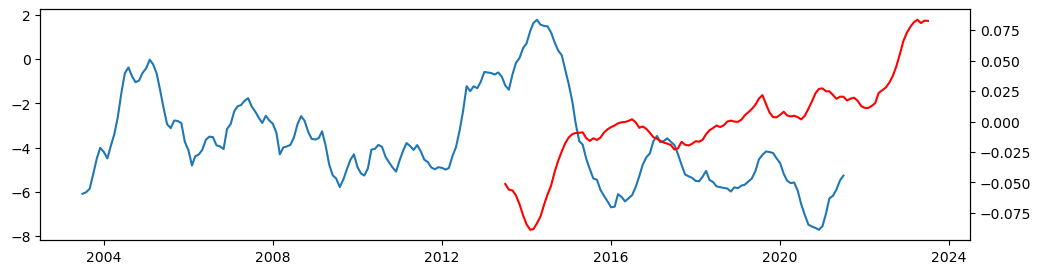

In [50]:
fig, ax = plt.subplots(1,1,figsize=(12,3))
ax.plot(cssh.time,cssh.rolling({'time':12},center=True).mean())
ax.twinx().plot(var1.time,var1.rolling({'time':12},center=True).mean(),c='r')